In [3]:
import pandas as pd
import yfinance as yf

tickers = ["SPY",'EFA','IEF','GLD','VNQ']

raw_data = yf.download(
    tickers = tickers,
    start = '2005-01-01',
    end = '2026-01-01',
    interval = '1d',
    auto_adjust = False,
    actions = True,
    progress = False
)

print("数据形状：",raw_data.shape)

display(raw_data.head())

print("列名：")
print(raw_data.columns)

数据形状： (5283, 45)


Price       Adj Close                                              \
Ticker            EFA        GLD        IEF        SPY        VNQ   
Date                                                                
2005-01-03  28.500851  43.020000  47.438824  81.174614  22.350882   
2005-01-04  27.954489  42.740002  47.143467  80.182709  22.014959   
2005-01-05  27.936569  42.669998  47.221489  79.629364  21.283123   
2005-01-06  27.936569  42.150002  47.266048  80.034256  21.447090   
2005-01-07  27.811172  41.840000  47.227074  79.919548  21.399099   

Price      Capital Gains                      ... Stock Splits                 \
Ticker               EFA  GLD  IEF  SPY  VNQ  ...          EFA  GLD  IEF  SPY   
Date                                          ...                               
2005-01-03           0.0  0.0  0.0  0.0  0.0  ...          0.0  0.0  0.0  0.0   
2005-01-04           0.0  0.0  0.0  0.0  0.0  ...          0.0  0.0  0.0  0.0   
2005-01-05           0.0  0.0  0.0  0.0  0.0  ...          0.0  0.0  0.0  0.0   
2005-01-06           0.0  0.0  0.0  0.0  0.0  ...          0.0  0.0  0.0  0.0   
2005-01-07           0.0  0.0  0.0  0.0  0.0  ...          0.0  0.0  0.0  0.0   

Price             Volume                                     
Ticker      VNQ      EFA      GLD      IEF       SPY    VNQ  
Date                                                         
2005-01-03  0.0  5273700  4750400   323400  55748000  31900  
2005-01-04  0.0  2983800  3456800  1181000  69167600  52500  
2005-01-05  0.0  3143700  2033600   369000  65667300  77300  
2005-01-06  0.0  2673300  2556400   389100  47814700  42200  
2005-01-07  0.0  2475300  4492700   182400  55847700  24200  

[5 rows x 45 columns]

列名：
MultiIndex([(    'Adj Close', 'EFA'),
            (    'Adj Close', 'GLD'),
            (    'Adj Close', 'IEF'),
            (    'Adj Close', 'SPY'),
            (    'Adj Close', 'VNQ'),
            ('Capital Gains', 'EFA'),
            ('Capital Gains', 'GLD'),
            ('Capital Gains', 'IEF'),
            ('Capital Gains', 'SPY'),
            ('Capital Gains', 'VNQ'),
            (        'Close', 'EFA'),
            (        'Close', 'GLD'),
            (        'Close', 'IEF'),
            (        'Close', 'SPY'),
            (        'Close', 'VNQ'),
            (    'Dividends', 'EFA'),
            (    'Dividends', 'GLD'),
            (    'Dividends', 'IEF'),
            (    'Dividends', 'SPY'),
            (    'Dividends', 'VNQ'),
            (         'High', 'EFA'),
            (         'High', 'GLD'),
            (         'High', 'IEF'),
            (         'High', 'SPY'),
            (         'High', 'VNQ'),
            (          'Low', 'EFA'),
        

列名有两层，是因为一列需要同时说明两件事：
1. Price
2. 哪支ETF

现在把45列缩减为模型真正需要的5列：

In [4]:
adj_close = raw_data["Adj Close"].copy()

print("调整收盘价形状：", adj_close.shape)
display(adj_close.head())

调整收盘价形状： (5283, 5)


Ticker,EFA,GLD,IEF,SPY,VNQ
Date,,,,,
2005-01-03,28.500851,43.020000,47.438824,81.174614,22.350882
2005-01-04,27.954489,42.740002,47.143467,80.182709,22.014959
2005-01-05,27.936569,42.669998,47.221489,79.629364,21.283123
2005-01-06,27.936569,42.150002,47.266048,80.034256,21.447090
2005-01-07,27.811172,41.840000,47.227074,79.919548,21.399099


接着检查数据质量：

In [5]:
print('每列缺失值数量：',adj_close.isna().sum())

print('\n开始日期：',adj_close.index.min())
print('\n结束日期：',adj_close.index.max())

print('\nDuplicated date:',adj_close.index.duplicated().sum())
#看开始结束，中间是否有缺失值，是否重复

每列缺失值数量： Ticker
EFA    0
GLD    0
IEF    0
SPY    0
VNQ    0
dtype: int64

开始日期： 2005-01-03 00:00:00

结束日期： 2025-12-31 00:00:00

Duplicated date: 0


数据检查通过：
- 五只ETF均没有缺失值；
- 日期覆盖2005年1月3日至2025年12月31日；
- 没有重复日期。
因此暂时不需要删除或填补数据。下一步把日度价格转成月度收益率。

In [6]:
monthly_prices = adj_close.resample('ME').last()

monthly_returns = (
    monthly_prices
    .pct_change(fill_method = None)
    .dropna()
)

print('Monthly prices shape:',monthly_prices.shape)
print('Monthly returns shape:',monthly_returns.shape)

display(monthly_prices.head())
display(monthly_returns.head().style.format('{:.2%}'))

Monthly prices shape: (252, 5)
Monthly returns shape: (251, 5)


Ticker,EFA,GLD,IEF,SPY,VNQ
Date,,,,,
2005-01-31,28.160490,42.220001,47.756496,79.730598,20.679272
2005-02-28,29.226362,43.529999,47.103046,81.397285,21.335114
2005-03-31,28.459652,42.820000,46.912956,79.908264,20.970821
2005-04-30,27.999266,43.349998,48.093529,78.411194,22.180832
2005-05-31,27.757435,41.650002,48.977600,80.937981,22.961884


Ticker,EFA,GLD,IEF,SPY,VNQ
Date,,,,,
2005-02-28 00:00:00,3.78%,3.10%,-1.37%,2.09%,3.17%
2005-03-31 00:00:00,-2.62%,-1.63%,-0.40%,-1.83%,-1.71%
2005-04-30 00:00:00,-1.62%,1.24%,2.52%,-1.87%,5.77%
2005-05-31 00:00:00,-0.86%,-3.92%,1.84%,3.22%,3.52%
2005-06-30 00:00:00,1.43%,4.30%,0.48%,0.15%,4.60%


再检查收益率的基本统计特征：

In [7]:
summary = monthly_returns.describe().T
display(summary)
summary['mean'] = summary['mean'] * 100
summary['std'] = summary['std'] * 100
summary['min'] = summary['min'] * 100
summary['max'] = summary['max'] * 100
display(summary[['count','mean','std','min','max']].round(2))
"""
这一步主要检查：
- count是否全部相同；
- 是否存在低于 -100% 等明显错误；
- 是否出现异常巨大的收益率；
- 哪类资产平均收益较高；
- 哪类资产波动最大。
"""

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
EFA,251.0,0.006028,0.048510,-0.208348,-0.022631,0.009652,0.035461,0.142694
GLD,251.0,0.010114,0.048293,-0.161397,-0.020731,0.006320,0.042482,0.127865
IEF,251.0,0.002863,0.018849,-0.047350,-0.008632,0.001879,0.013558,0.077538
SPY,251.0,0.009488,0.042785,-0.165187,-0.013617,0.015116,0.035539,0.126984
VNQ,251.0,0.007740,0.062442,-0.317270,-0.026260,0.013367,0.042691,0.306837


,count,mean,std,min,max
Ticker,,,,,
EFA,251.0,0.60,4.85,-20.83,14.27
GLD,251.0,1.01,4.83,-16.14,12.79
IEF,251.0,0.29,1.88,-4.73,7.75
SPY,251.0,0.95,4.28,-16.52,12.70
VNQ,251.0,0.77,6.24,-31.73,30.68


'\n这一步主要检查：\n- count是否全部相同；\n- 是否存在低于 -100% 等明显错误；\n- 是否出现异常巨大的收益率；\n- 哪类资产平均收益较高；\n- 哪类资产波动最大。\n'

现在划出第一次模型估计使用的60个月：

下一步我们会用这60个月亲手计算每只资产的样本均值和 5×5协方差矩阵。

In [8]:
window = 60

estimation_sample = monthly_returns.iloc[:window]
oos_return = monthly_returns.iloc[window]

print('Number of estimation months:',len(estimation_sample))
print('Estimation Start:',estimation_sample.index[0])
print('Estimation end:',estimation_sample.index[-1])
print('Out-of-sample months:',oos_return.name)

display(oos_return.to_frame('Return').style.format('{:.2%}'))


Number of estimation months: 60
Estimation Start: 2005-02-28 00:00:00
Estimation end: 2010-01-31 00:00:00
Out-of-sample months: 2010-02-28 00:00:00


,Return
Ticker,
EFA,0.27%
GLD,3.27%
IEF,0.33%
SPY,3.12%
VNQ,5.58%


下一步计算第一次60个月窗口中的两个模型输入：

In [9]:
mu_hat = estimation_sample.mean()
cov_hat = estimation_sample.cov()

print('Estimated monthly mean returns:')
display(mu_hat.to_frame('Mean').style.format('{:.2%}'))

print("Estimated monthly covariance matrix:")
display(cov_hat.style.format('{:.6f}'))


Estimated monthly mean returns:


,Mean
Ticker,
EFA,0.39%
GLD,1.70%
IEF,0.46%
SPY,0.12%
VNQ,0.56%


Estimated monthly covariance matrix:


Ticker,EFA,GLD,IEF,SPY,VNQ
Ticker,,,,,
EFA,0.003513,0.000888,-0.000069,0.002503,0.004150
GLD,0.000888,0.003149,0.000283,0.000259,0.000342
IEF,-0.000069,0.000283,0.000423,-0.000122,-0.000202
SPY,0.002503,0.000259,-0.000122,0.002158,0.003460
VNQ,0.004150,0.000342,-0.000202,0.003460,0.008533


In [10]:
import numpy as np

assets = estimation_sample.columns
n_assets = len(assets)

w_ew = pd.Series(
    np.repeat(1/n_assets,n_assets),
    index = assets,
    name = 'EW'
)

display(w_ew.to_frame('Weight').style.format('{:.2%}'))
print('Weight sum',w_ew.sum())


,Weight
Ticker,
EFA,20.00%
GLD,20.00%
IEF,20.00%
SPY,20.00%
VNQ,20.00%


Weight sum 1.0


In [11]:
ew_mean = w_ew @ mu_hat
ew_var = w_ew @ cov_hat @ w_ew
ew_vol = np.sqrt(ew_var)

print(f'Estimated monthly mean return:{ew_mean:.2%}')
print(f'Estimated monthly volatility:{ew_vol:.2%}')


Estimated monthly mean return:0.65%
Estimated monthly volatility:4.04%


In [ ]:
from scipy.optimize import minimize

cov_matrix = cov_hat.to_numpy()

def portfolio_variance(weights,cov_matrix):
    return weights @ cov_matrix @ weights

initial_weights = np.repeat(1/n_assets,n_assets)

bounds = [(0,1)] * n_assets


gmv_result = minimize(
    fun = portfolio_variance,
    x0 = initial_weights,
    args = (cov_matrix,),
    method = 'SLSQP',
    bounds = bounds,
    constraints = {
    "type" : 'eq',
    'fun' : lambda weights:weights.sum() -1
}
    
)

print('Optimization success:' , gmv_result.success)
print('Message:' , gmv_result.message)

w_gmv = pd.Series(
    gmv_result.x,
    index=assets,
    name="GMV"
)

display(w_gmv.to_frame("Weight").style.format("{:.2%}"))
print("Weight sum:", w_gmv.sum())

"""
gmv_result.success  # 是否成功
gmv_result.message  # 停止原因
gmv_result.x        # 最优权重
gmv_result.fun      # 最小组合方差
gmv_result.nit      # 迭代次数
"""

Optimization success: True
Message: Optimization terminated successfully


,Weight
Ticker,
EFA,0.00%
GLD,1.49%
IEF,79.87%
SPY,18.47%
VNQ,0.17%


Weight sum: 1.0


'\ngmv_result.success  # 是否成功\ngmv_result.message  # 停止原因\ngmv_result.x        # 最优权重\ngmv_result.fun      # 最小组合方差\ngmv_result.nit      # 迭代次数\n'

In [15]:
gmv_mean = w_gmv @ mu_hat
gmv_var = w_gmv @ cov_hat @ w_gmv
gmv_vol = np.sqrt(gmv_var)

in_sample_comparison = pd.DataFrame({
    'EW':[ew_mean,ew_vol],
    'GMV':[gmv_mean,gmv_vol]},
    index = ['Estiamted return','Estimated volatility'])

display(in_sample_comparison.style.format('{:.2%}'))

,EW,GMV
Estiamted return,0.65%,0.41%
Estimated volatility,4.04%,1.78%


In [21]:
ew_oos_return = w_ew @ mu_hat
gmv_oos_return = w_gmv @ mu_hat

oos_comparison = pd.DataFrame({
    "Out-of-sample return": [ew_oos_return, gmv_oos_return]
}, index=["EW", "GMV"])

display(oos_comparison.style.format('{:.2%}'))

,Out-of-sample return
EW,0.65%
GMV,0.41%


In [31]:
risk_aversion = 3

mu_vector = mu_hat.to_numpy()

def negative_mv_utility(
        weights,
        mu_vector,
        cov_matrix,
        risk_aversion
):
    portfolio_return = weights @ mu_vector
    portfolio_variance = weights @ cov_matrix @ weights

    utility = (
        portfolio_return
        - risk_aversion / 2* portfolio_variance
    )

    return -utility #是因为SciPy的 minimize()只能寻找最小值，而我们希望效用最大，所以返回负数

initial_weights = np.repeat(1/n_assets,n_assets)

mv_result = minimize(
    fun = negative_mv_utility,
    x0 = initial_weights,
    args = (mu_vector,cov_matrix,risk_aversion),
    method = 'SLSQP',
    bounds =[(0,1)] * n_assets,
    constraints = {
    'type' : 'eq',
    'fun' : lambda weights:weights.sum()-1
    }
)

print('Optimization success:',mv_result.success)

w_mv = pd.Series(
    mv_result.x,
    index = assets,
    name='MV'
)
display(w_mv.to_frame().style.format('{:.2%}'))



Optimization success: True


,MV
Ticker,
EFA,0.00%
GLD,100.00%
IEF,0.00%
SPY,0.00%
VNQ,0.00%


接下来先做风险厌恶系数 \(\gamma\) 的敏感性分析，观察MV权重为什么会变化

In [33]:
gamma_values = [1, 3, 5, 10, 20]

mv_weights_by_gamma = {}

for gamma in gamma_values:

    result = minimize(
        fun=negative_mv_utility,
        x0=initial_weights,
        args=(mu_vector, cov_matrix, gamma),
        method="SLSQP",
        bounds=bounds,
        constraints={
    'type' : 'eq',
    'fun' : lambda weights:weights.sum()-1
    }
    )

    mv_weights_by_gamma[f"Gamma={gamma}"] = result.x

mv_sensitivity = pd.DataFrame(
    mv_weights_by_gamma,
    index=assets
)

display(mv_sensitivity.style.format("{:.2%}"))

,Gamma=1,Gamma=3,Gamma=5,Gamma=10,Gamma=20
Ticker,,,,,
EFA,0.00%,0.00%,0.00%,0.00%,0.00%
GLD,100.00%,100.00%,86.81%,48.66%,23.07%
IEF,0.00%,0.00%,10.67%,46.57%,68.51%
SPY,0.00%,0.00%,0.00%,0.00%,5.30%
VNQ,0.00%,0.00%,2.51%,4.77%,3.13%


In [34]:
mv_stats_by_gamma = {}

for column in mv_sensitivity.columns:

    weights = mv_sensitivity[column]

    estimated_return = weights @ mu_hat
    estimated_volatility = np.sqrt(
        weights @ cov_hat @ weights
    )

    mv_stats_by_gamma[column] = [
        estimated_return,
        estimated_volatility
    ]

mv_gamma_comparison = pd.DataFrame(
    mv_stats_by_gamma,
    index=["Estimated return", "Estimated volatility"]
).T

display(mv_gamma_comparison.style.format("{:.2%}"))

,Estimated return,Estimated volatility
Gamma=1,1.70%,5.61%
Gamma=3,1.70%,5.61%
Gamma=5,1.54%,4.95%
Gamma=10,1.07%,3.15%
Gamma=20,0.73%,2.18%


In [39]:
from tkinter import EW


risk_aversion = 10

rolling_results = []
rolling_dates = []

gmv_weights_history = []
mv_weights_history = []

for end in range(window,len(monthly_returns)):
    estimation_window = monthly_returns.iloc[
        end - window:end
    ]

    next_month_return = monthly_returns.iloc[end]

    mu_t = estimation_window.mean().to_numpy()
    cov_t = estimation_window.cov().to_numpy()

    #EW
    w_ew_t = np.repeat(
        1/n_assets,
        n_assets
    )

    #GMV
    gmv_result = minimize(
        fun = portfolio_variance,
        x0 = initial_weights,
        args = (cov_t,),
        method = 'SLSQP',
        bounds = [(0,1)] *n_assets,
        constraints = {
            "type": "eq",
            "fun": lambda x: np.sum(x) - 1
        }
    )

    #MV
    mv_result = minimize(
        fun = negative_mv_utility,
        x0 = initial_weights,
        args = (mu_t,cov_t,risk_aversion),
        method = 'SLSQP',
        bounds = [(0,1)] *n_assets,
        constraints = {
            "type": "eq",
            "fun": lambda x: np.sum(x) - 1
        }
    )

    if not gmv_result.success:
        raise RuntimeError(
            f"GMV optimization failed at {next_month_return.name}"
        )

    if not mv_result.success:
        raise RuntimeError(
            f"MV optimization failed at {next_month_return.name}"
        )

    w_gmv_t = gmv_result.x
    w_mv_t = mv_result.x

    actual_returns = next_month_return.to_numpy()

    rolling_results.append({
        'EW':w_ew_t @actual_returns,
        'GMV':w_gmv_t @ actual_returns,
        'MV':w_mv_t @ actual_returns
    })

    rolling_dates.append(
        next_month_return.name
    )

    gmv_weights_history.append(w_gmv_t)
    mv_weights_history.append(w_mv_t)

oos_returns = pd.DataFrame(
    rolling_results,
    index = rolling_dates
)

gmv_weights_history = pd.DataFrame(
    gmv_weights_history,
    index = rolling_dates,
    columns = assets
)

print('OOS returns shape:',oos_returns.shape)

display(
    oos_returns.head().style.format('{:.2%}')
)

OOS returns shape: (191, 3)


,EW,GMV,MV
2010-02-28 00:00:00,2.52%,0.90%,2.01%
2010-03-31 00:00:00,4.23%,0.25%,-0.22%
2010-04-30 00:00:00,2.69%,1.65%,4.07%
2010-05-31 00:00:00,-3.70%,1.01%,2.39%
2010-06-30 00:00:00,-1.41%,1.63%,2.26%


In [42]:
n_months = len(oos_returns)

total_return = (
    (1 + oos_returns).prod() -1
)

annualized_return = (
    (1 + oos_returns).prod()
    ** (12/n_months)
    -1
)

annulized_volatility = (
    oos_returns.std() * np.sqrt(12)
)

sharpe_ratio = (
    oos_returns.mean()
    /oos_returns.std()
    * np.sqrt(12)
)

cumulative_wealth = (
    1 + oos_returns
).cumprod()

drawdown = (
    cumulative_wealth
    / cumulative_wealth.cummax()
    - 1
)

max_drawdown = drawdown.min()

performance_summary = pd.DataFrame(
    {
        'Total Return':total_return,
        'Annualized Return':annualized_return,
        'Annualized Volatility':annulized_volatility,
        'Sharpe Ratio':sharpe_ratio,
        'Max Drawdown':max_drawdown
    }
)

display(
    performance_summary.style.format({
        "Total Return":'{:.2%}',
        'Annualized Return':'{:.2%}',
        'Annualized Volatility':'{:.2%}',
        'Sharpe Ratio':'{:.2f}',
        'Max Drawdown':'{:.2%}'
    })
)

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
EW,285.38%,8.85%,9.92%,0.91,-21.12%
GMV,183.01%,6.75%,7.06%,0.96,-15.93%
MV,384.39%,10.42%,9.31%,1.11,-19.68%





累计财富曲线；
GMV和MV的平均换手率；
总结为什么三种策略表现不同。

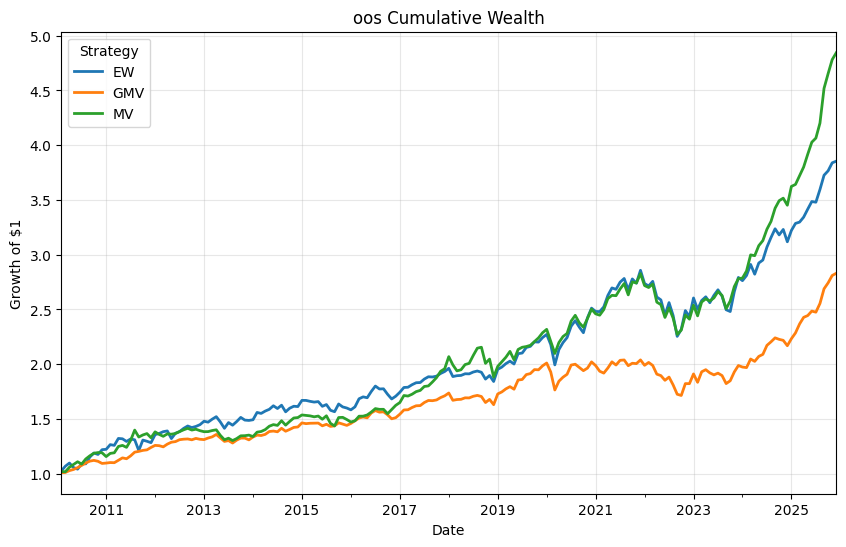

In [44]:
import matplotlib.pyplot as plt

cumulative_wealth = (
    1+oos_returns
).cumprod()

ax = cumulative_wealth.plot(
    figsize= (10,6),
    linewidth =2
)

ax.set_title('oos Cumulative Wealth')
ax.set_xlabel("Date")
ax.set_ylabel('Growth of $1')
ax.grid(True,alpha = 0.3)
ax.legend(title = 'Strategy')

plt.show()
